# Guía para Análisis Exploratorio de Datos (EDA)

## Paso 1: Inspección General (Data Understanding)
El objetivo aquí es conocer la forma y la naturaleza básica de tu dataset.

*   **Estructura**: Revisar la cantidad de filas y columnas (`df.shape`).
*   **Tipos de Datos**: Identificar qué columnas son numéricas, categóricas o temporales (`df.info()`, `df.dtypes`).
*   **Muestra**: Observar las primeras y últimas filas para entender el contexto real de los datos (`df.head()`, `df.tail()`).
*   **Estadística Descriptiva**: Obtener un resumen de la media, desviación estándar, mínimos y máximos de las variables numéricas (`df.describe()`).

## Paso 2: Limpieza y Calidad de Datos (Data Quality & Cleaning)
Antes de buscar patrones, hay que asegurar que los datos sean confiables.

*   **Valores Nulos**: Cuantificar la cantidad de datos faltantes por columna (`df.isnull().sum()`) y decidir si se imputan (rellenan) o se eliminan.
*   **Duplicados**: Identificar y remover filas exactamente iguales que puedan sesgar el análisis (`df.duplicated()`).
*   **Inconsistencias**: Corregir errores tipográficos en variables categóricas o formatos de fecha incorrectos.

## Paso 3: Análisis Univariado (Univariate Analysis)
Analizar cada variable de forma individual para entender su distribución.

*   **Variables Numéricas**: Usar histogramas para ver la distribución de frecuencias y boxplots (diagramas de caja) para identificar valores atípicos (outliers).
*   **Variables Categóricas**: Usar gráficos de barras o conteos de frecuencia (`value_counts()`) para ver la proporción de cada categoría.

## Paso 4: Análisis Bivariado y Multivariado (Multivariate Analysis)
Aquí es donde comienza la magia: encontrar las relaciones entre diferentes variables.

*   **Correlación**: Crear una matriz de correlación (heatmap) para ver qué variables numéricas se mueven juntas (ej. velocidad vs. RPM).
*   **Dispersión (Scatter Plots)**: Graficar pares de variables para identificar tendencias o agrupaciones (clusters).
*   **Segmentación**: Agrupar datos numéricos por categorías (ej. velocidad promedio agrupada por cada piloto) usando `groupby`.

## Paso 5: Generación de Insights (Feature Engineering Preliminar)
Basado en lo que observaste en los pasos anteriores, tomas decisiones sobre las variables.

*   **Creación**: Derivar nuevas columnas útiles (ej. crear una columna "tiempo de vuelta en segundos" a partir de un timestamp).
*   **Transformación**: Aplicar logaritmos o normalización si los datos están muy sesgados.
*   **Selección**: Descartar columnas que tienen el 99% de valores nulos o que no aportan varianza al estudio.

Paso 6: Resumen y Conclusiones (Reporting)
El cierre del pipeline no es código, es comunicación.

Documentación: Anotar los hallazgos principales, las limitaciones del dataset y cómo se trataron los valores atípicos o nulos.
Preparación para la siguiente fase: Exportar el dataset "limpio" y listo para el modelado o la creación de dashboards (df.to_csv() o df.to_parquet()).

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cargar el dataset de Japón
df_japan = pd.read_parquet("japan_2026.parquet")

# Inspección básica
print(df_japan.shape)
print(df_japan.columns.tolist())
display(df_japan.head())

(106, 19)
['meeting_key', 'session_key', 'driver_number', 'lap_number', 'date_start', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed', 'i2_speed', 'is_pit_out_lap', 'lap_duration', 'segments_sector_1', 'segments_sector_2', 'segments_sector_3', 'st_speed', 'pit_duration', 'PitStop', 'fuel_load_est']


,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed,pit_duration,PitStop,fuel_load_est
0,1281,11253,16,1,2026-03-29T05:14:02.078000+00:00,36.900,41.648,18.305,267.0,320,False,96.853,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2051, 2049, 2049, 2049, 2049, 2049, 205...","[2049, 2049, 2049, 2049, 2049, 2049, 2049]",283,NaN,0,105.0
1,1281,11253,16,2,2026-03-29T05:15:38.930000+00:00,34.987,42.055,18.084,258.0,325,False,95.126,"[2049, 2049, 2049, 2051, 2049, 2049, 2049, 204...","[2048, 2048, 2049, 2048, 2049, 2048, 2048, 205...","[2049, 2049, 2049, 2049, 2048, 2048, 2048]",285,NaN,0,103.018868
2,1281,11253,16,3,2026-03-29T05:17:14.047000+00:00,35.159,41.807,18.139,260.0,319,False,95.105,"[2048, 2048, 2048, 2051, 2048, 2048, 2048, 204...","[2048, 2048, 2048, 2049, 2048, 2048, 2048, 204...","[2048, 2048, 2049, 2048, 2048, 2048, 2048]",282,NaN,0,101.037736
3,1281,11253,16,4,2026-03-29T05:18:49.142000+00:00,35.751,42.366,18.314,258.0,317,False,96.431,"[None, 2048, 2048, 2048, 2048, 2048, 2048, 204...","[2049, 2048, 2048, 2048, 2048, 2048, 2048, 204...","[2048, 2048, 2048, 2048, 2048, 2049, 2049]",283,NaN,0,99.056604
4,1281,11253,16,5,2026-03-29T05:20:25.607000+00:00,34.819,42.188,18.202,257.0,319,False,95.209,"[2049, 2049, 2049, 2048, 2048, 2048, 2048, 204...","[2048, 2048, 2049, 2048, 2048, 2048, 2048, 204...","[2048, 2048, 2048, 2048, 2048, 2049, 2048]",284,NaN,0,97.075472


In [22]:
# 1. Eliminar vueltas sin duración de vuelta (dato crítico)
df_japan = df_japan.dropna(subset=['lap_duration'])

# 2. Rellenar pit_duration con 0 (si es nulo es porque no hubo parada)
df_japan['pit_duration'] = df_japan['pit_duration'].fillna(0)

# 3. Imputación con la MEDIANA (para evitar sesgo de atípicos en sectores y velocidad)
cols_impute = ['duration_sector_1', 'duration_sector_2', 'duration_sector_3',
               'i1_speed', 'i2_speed', 'st_speed']
for col in cols_impute:
    df_japan[col] = df_japan.groupby('driver_number')[col].transform(
        lambda x: x.fillna(x.median())
    )

,meeting_key,session_key,driver_number,lap_number,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,lap_duration,st_speed,pit_duration,PitStop,fuel_load_est
count,106.0,106.0,106.0,106.0,106.000,106.000,106.000,106.000,106.000,106.000,106.000,106.000,106.000,106.0
mean,1281.0,11253.0,30.0,27.0,36.517,44.347,19.212,251.453,303.528,100.076,273.755,0.431,0.019,53.491
std,0.0,0.0,14.067,15.37,5.756,7.605,3.096,27.802,50.338,15.836,34.152,3.124,0.137,30.449
min,1281.0,11253.0,16.0,1.0,33.676,40.919,17.707,126.000,114.000,92.634,120.000,0.000,0.000,1.981
25%,1281.0,11253.0,16.0,14.0,34.174,41.388,17.981,257.250,313.000,93.659,280.000,0.000,0.000,27.736
50%,1281.0,11253.0,30.0,27.0,34.690,41.811,18.126,260.000,317.000,94.902,283.000,0.000,0.000,53.491
75%,1281.0,11253.0,44.0,40.0,35.020,42.183,18.260,262.000,325.000,95.444,286.000,0.000,0.000,79.245
max,1281.0,11253.0,44.0,53.0,64.944,71.609,30.437,270.000,339.000,157.390,298.000,22.900,1.000,105.0


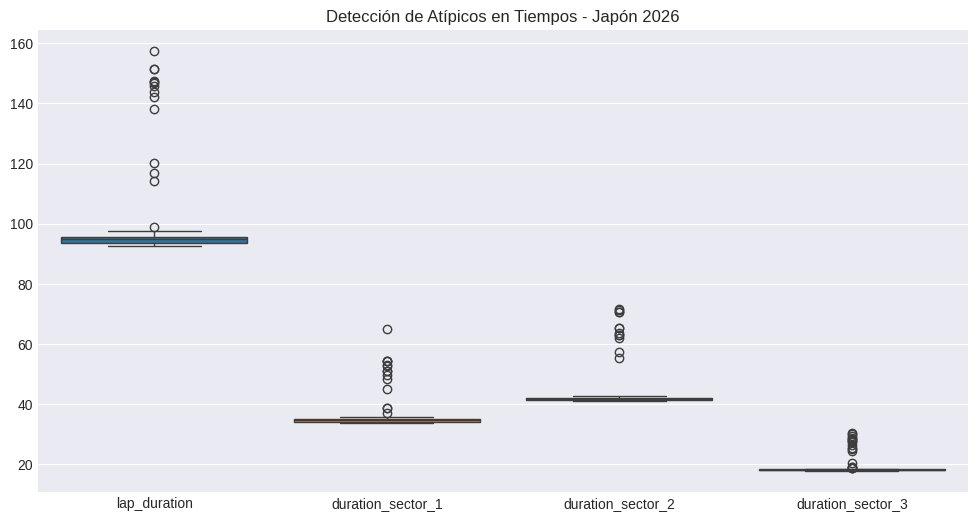

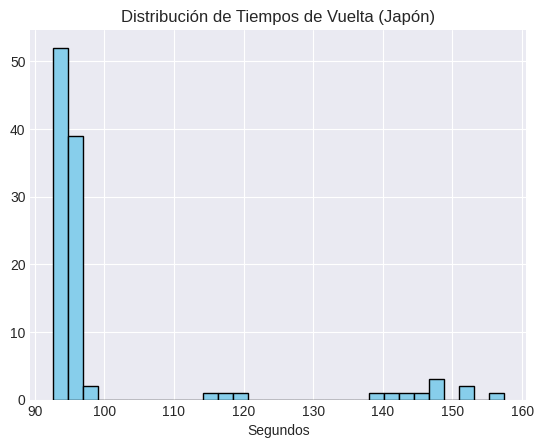

In [23]:
# Estadísticas descriptivas de tablas idénticas
num_cols = df_japan.select_dtypes(include='number').columns.tolist()
display(df_japan[num_cols].describe().round(3))

# Boxplot para detectar Atípicos (Outliers)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_japan[['lap_duration', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3']])
plt.title("Detección de Atípicos en Tiempos - Japón 2026")
plt.show()

# Histograma de distribución
df_japan['lap_duration'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("Distribución de Tiempos de Vuelta (Japón)")
plt.xlabel("Segundos")
plt.show()

In [24]:
Q1 = df_japan['lap_duration'].quantile(0.25)
Q3 = df_japan['lap_duration'].quantile(0.75)
IQR = Q3 - Q1
# Definir límites
limite_superior = Q3 + 1.5 * IQR
# Filtrar el dataframe
df_japan_clean = df_japan[df_japan['lap_duration'] <= limite_superior]

Top 10 Vueltas Rápidas en Japón:


,driver_number,lap_number,lap_duration
52,16,53,92.634
100,44,48,92.777
50,16,51,92.897
47,16,48,93.011
46,16,47,93.122
37,16,38,93.128
45,16,46,93.160
51,16,52,93.201
42,16,43,93.205
34,16,35,93.252


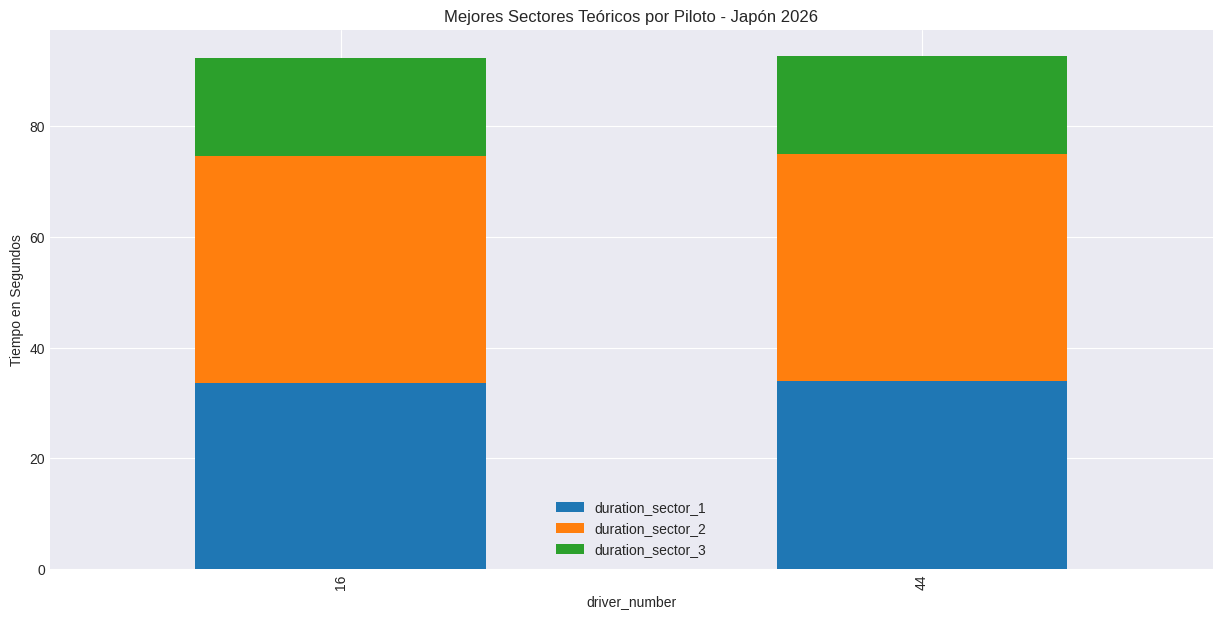

In [25]:
# 1. Filtrar solo vueltas lanzadas (quitando In-laps y Out-laps si tienes la columna is_pit_out_lap)
df_lanzadas = df_japan[df_japan['is_pit_out_lap'] == False]

# 2. Top 10 Vueltas más rápidas del GP
fastest_laps = df_lanzadas.sort_values(by='lap_duration').head(10)
print("Top 10 Vueltas Rápidas en Japón:")
display(fastest_laps[['driver_number', 'lap_number', 'lap_duration']])

# 3. Comparación de Sectores (Copia el estilo de barras de Australia)
sectores = df_lanzadas.groupby('driver_number')[['duration_sector_1', 'duration_sector_2', 'duration_sector_3']].min()
sectores.plot(kind='bar', stacked=True, figsize=(15,7))
plt.title("Mejores Sectores Teóricos por Piloto - Japón 2026")
plt.ylabel("Tiempo en Segundos")
plt.show()

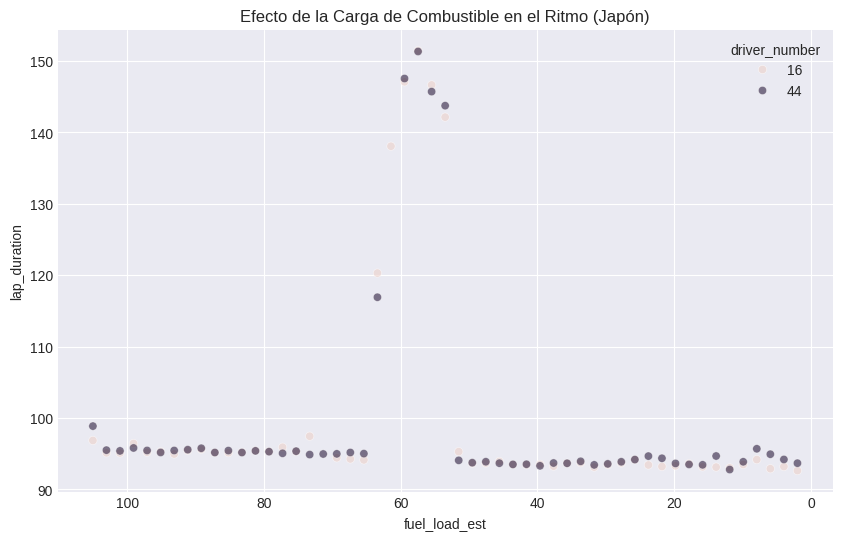

In [26]:
# Scatter plot: Relación Combustible vs Tiempo de Vuelta
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_lanzadas, x='fuel_load_est', y='lap_duration', hue='driver_number', alpha=0.6)
plt.title("Efecto de la Carga de Combustible en el Ritmo (Japón)")
plt.gca().invert_xaxis() # El combustible baja a lo largo de la carrera
plt.show()

In [27]:
# Crear un resumen de consistencia
resumen_ritmo = df_lanzadas.groupby('driver_number').agg({
    'lap_duration': ['mean', 'std', 'min'],
    'st_speed': 'max'
}).reset_index()

# Renombrar columnas para que sea legible
resumen_ritmo.columns = ['Piloto', 'Promedio', 'Consistencia (Std)', 'Vuelta Rápida', 'Top Speed']
display(resumen_ritmo.sort_values(by='Vuelta Rápida'))

,Piloto,Promedio,Consistencia (Std),Vuelta Rápida,Top Speed
0,16,99.708250,15.477855,92.634,298
1,44,99.067827,14.393364,92.777,296


/tmp/ipykernel_989/2269111263.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_japan, x='driver_number', y='st_speed', palette='viridis')


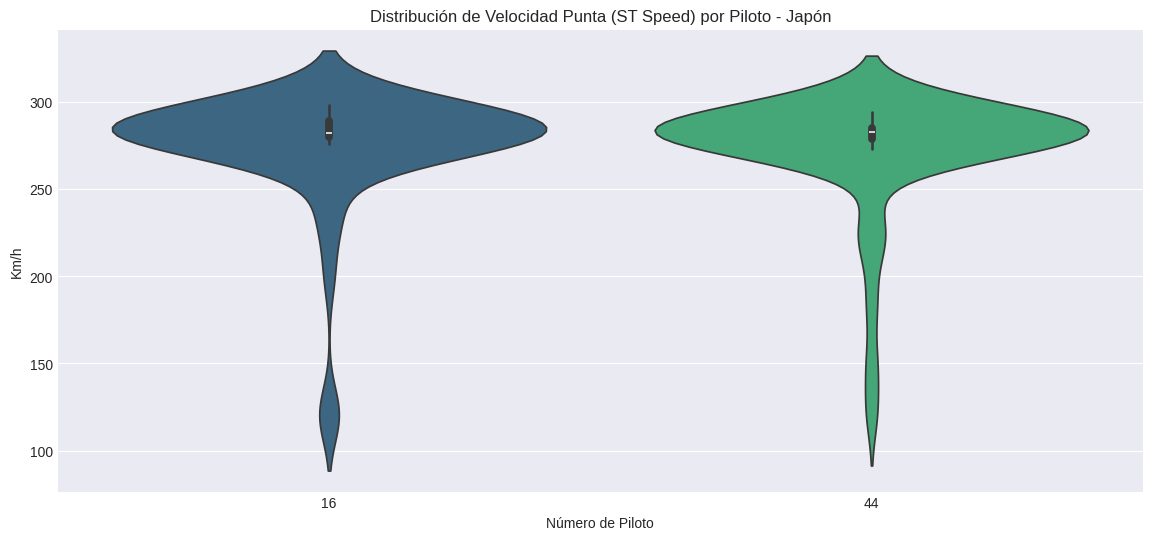

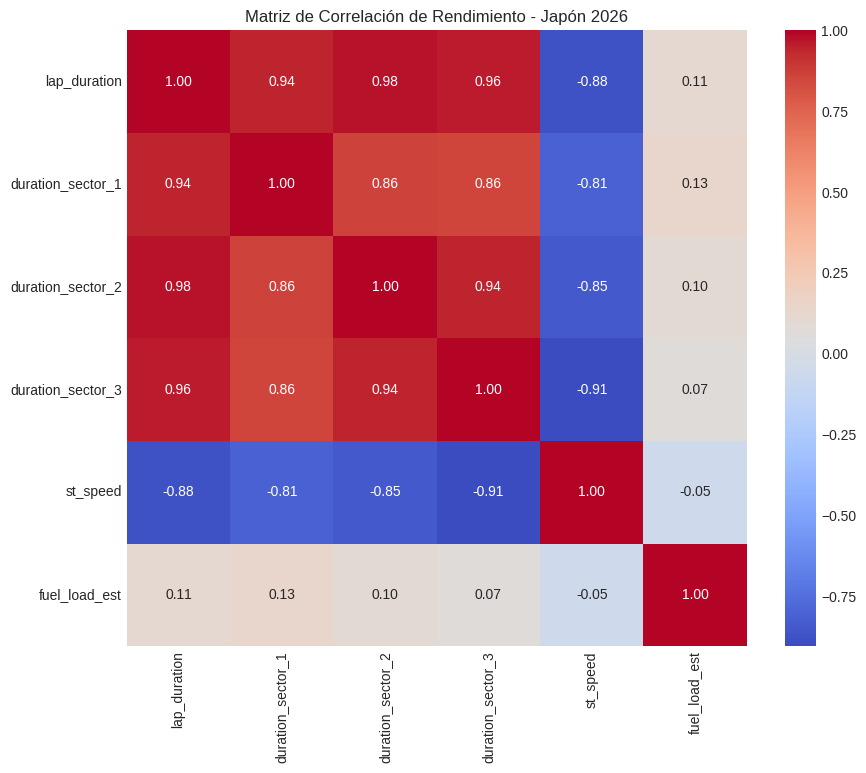

In [28]:
# Gráfico de violín para comparar velocidades entre pilotos
plt.figure(figsize=(14, 6))
sns.violinplot(data=df_japan, x='driver_number', y='st_speed', palette='viridis')
plt.title("Distribución de Velocidad Punta (ST Speed) por Piloto - Japón")
plt.ylabel("Km/h")
plt.xlabel("Número de Piloto")
plt.show()

# Correlación entre sectores y velocidad (Idéntico al mapa de calor de Australia)
corr_matrix = df_japan[['lap_duration', 'duration_sector_1', 'duration_sector_2',
                        'duration_sector_3', 'st_speed', 'fuel_load_est']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Rendimiento - Japón 2026")
plt.show()

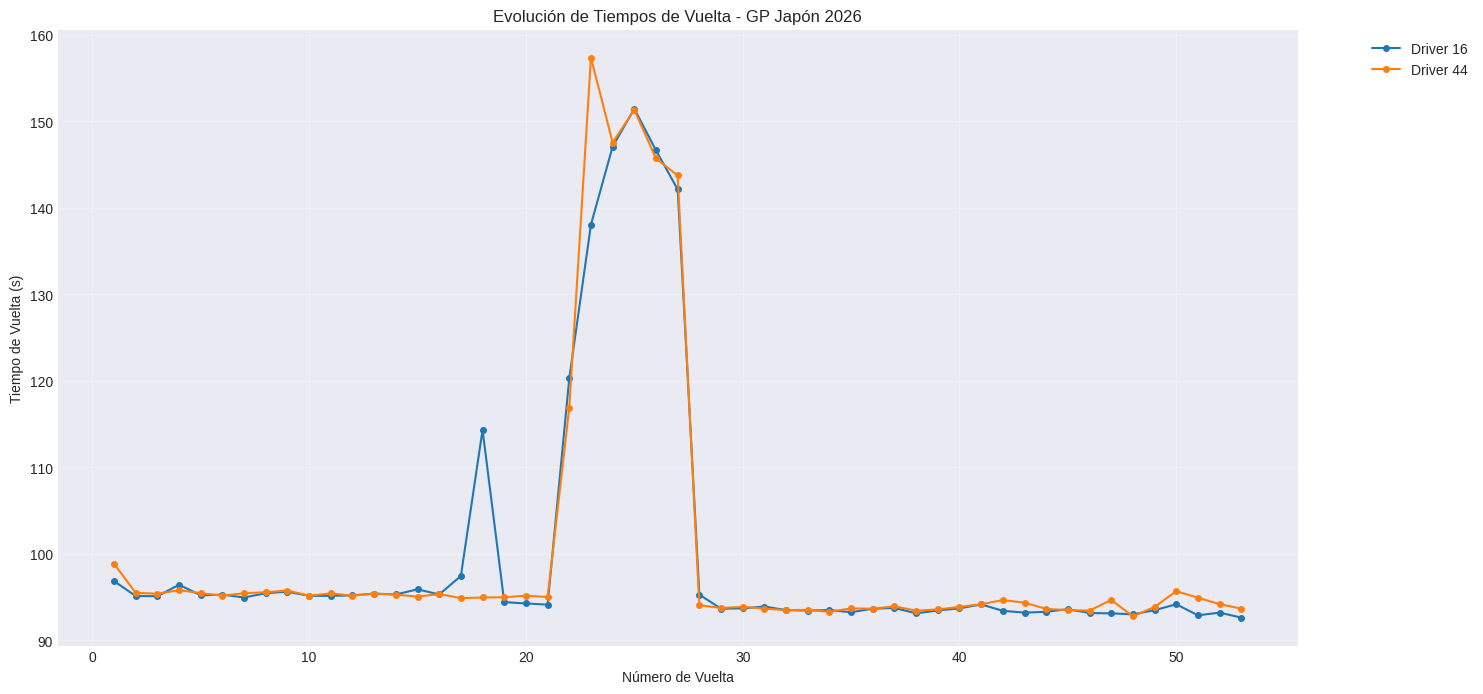

In [29]:
# Gráfico de líneas de tiempos de vuelta por piloto
plt.figure(figsize=(16, 8))
for driver in df_japan['driver_number'].unique():
    subset = df_japan[df_japan['driver_number'] == driver]
    plt.plot(subset['lap_number'], subset['lap_duration'], label=f'Driver {driver}', marker='o', markersize=4)

plt.title("Evolución de Tiempos de Vuelta - GP Japón 2026")
plt.xlabel("Número de Vuelta")
plt.ylabel("Tiempo de Vuelta (s)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# Definir columnas de interés
resumen_cols = ['lap_duration', 'duration_sector_1', 'duration_sector_2',
                'duration_sector_3', 'i1_speed', 'i2_speed', 'st_speed', 'fuel_load_est']

# Aplicar relleno antes del resumen final (Mean para métricas de tiempo)
df_resumen = df_japan.copy()
for col in resumen_cols:
    df_resumen[col] = df_resumen[col].fillna(df_resumen[col].mean())

# Creación de la tabla de métricas agregadas
tabla_final = df_resumen.groupby('driver_number')[resumen_cols].agg(['mean', 'median', 'std', 'min', 'max'])

# Limpiar nombres de columnas
tabla_final.columns = ['_'.join(col).strip() for col in tabla_final.columns.values]

print("Resumen Estadístico Final - Japón 2026 (Procesado)")
display(tabla_final.round(3))

Resumen Estadístico Final - Japón 2026 (Procesado)


,lap_duration_mean,lap_duration_median,lap_duration_std,lap_duration_min,lap_duration_max,duration_sector_1_mean,duration_sector_1_median,duration_sector_1_std,duration_sector_1_min,duration_sector_1_max,...,st_speed_mean,st_speed_median,st_speed_std,st_speed_min,st_speed_max,fuel_load_est_mean,fuel_load_est_median,fuel_load_est_std,fuel_load_est_min,fuel_load_est_max
driver_number,,,,,,,,,,,,,,,,,,,,,
16,99.984,94.266,15.459,92.634,151.474,36.489,34.659,5.401,33.676,54.354,...,274.604,282.0,34.802,120,298,53.491,53.491,30.596,1.981,105.0
44,100.168,94.959,16.351,92.777,157.390,36.545,34.796,6.142,33.962,64.944,...,272.906,283.0,33.800,122,296,53.491,53.491,30.596,1.981,105.0
